# 04 Classification Modeling - Promise Band

Predict `under_half`, `half_to_full` or `late` using the existing Top16 feature set. The formal workflow compares fixed models and tunes Logistic Regression with temporal cross-validation, freezes candidates, then refits on Train + Validation for final Test evaluation. Earlier single-validation experiments are retained as historical evidence.

## 0. Setup and Load Data

Read the current processed feature table and selected_features.csv.

In [1]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from scipy.sparse import csr_matrix
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, matthews_corrcoef,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

ROOT = Path.cwd()
if not (ROOT / "notebooks").is_dir():
    ROOT = ROOT.parent
DATA = ROOT / "data/data/processed"
RANDOM_STATE = 42
TARGET = "promise_band"
BANDS = ["under_half", "half_to_full", "late"]
pd.set_option("display.max_columns", None)

df = pd.read_csv(DATA / "promise_band_feature_table.csv", parse_dates=[
    "order_purchase_timestamp", "order_delivered_customer_date",
])
selected_features = pd.read_csv(DATA / "selected_features.csv")
print("Dataset shape:", df.shape)


D:\Anaconda\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\Anaconda\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


Dataset shape: (96470, 83)


## 1. Prepare Time-Ordered Train / Validation / Test

Keep the existing temporal split: train 64,429; validation 12,541; test 14,471. The 5,029 excluded orders do not enter training or evaluation.

In [2]:
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "val"].copy()
test_df = df[df["split"] == "test"].copy()

assert df["split"].value_counts().to_dict() == {
    "train": 64429, "val": 12541, "test": 14471, "excluded": 5029,
}
assert df["order_id"].is_unique and df[TARGET].notna().all()
assert set(df[TARGET]) == set(BANDS)
assert train_df["order_purchase_timestamp"].max() < val_df["order_purchase_timestamp"].min()
assert val_df["order_purchase_timestamp"].max() < test_df["order_purchase_timestamp"].min()
assert train_df["order_delivered_customer_date"].lt(val_df["order_purchase_timestamp"].min()).all()
assert val_df["order_delivered_customer_date"].lt(test_df["order_purchase_timestamp"].min()).all()

splits = {"Val": val_df, "Test": test_df}
split_summary = pd.DataFrame([
    {"split": name, "n": len(frame), **{
        f"{band} (%)": frame[TARGET].eq(band).mean() * 100 for band in BANDS
    }}
    for name, frame in [("Train", train_df), *splits.items()]
])
display(split_summary.round(2))
print("Excluded (not used):", df["split"].eq("excluded").sum())


,split,n,under_half (%),half_to_full (%),late (%)
0,Train,64429,55.25,36.80,7.95
1,Val,12541,70.54,24.07,5.38
2,Test,14471,60.74,32.65,6.61


Excluded (not used):

 5029


## 2. Load Selected Features

The latest selected_features.csv supplies 16 features in saved rank order. Read them dynamically; do not hardcode feature names or repeat feature selection.

In [3]:
features = selected_features.sort_values("rank", kind="stable")["feature"].tolist()
assert features and len(features) == len(set(features))
assert set(features).issubset(df.columns)
assert not set(features).intersection({
    TARGET, "split", "order_id", "customer_unique_id", "seller_id",
    "actual_days", "duration_ratio", "order_purchase_timestamp",
    "order_delivered_customer_date", "order_delivered_carrier_date",
    "order_status", "order_approved_at", "review_score",
})

X_train = train_df[features]
y_train = train_df[TARGET]
print("Selected features:", len(features))
print(features)


Selected features: 16
['promised_days', 'route_prior_under_half_rate', 'distance_km', 'route_prior_mean_actual_days', 'freight_mean', 'seller_prior_mean_actual_days', 'customer_lat', 'customer_state', 'product_category', 'customer_lng', 'category_prior_mean_ratio', 'route_prior_delivered', 'seller_lat', 'seller_prior_under_half_rate', 'market_30d_late_rate', 'n_sellers']


## 3. Build Preprocessing

Use median imputation for numeric features and most-frequent imputation plus one-hot encoding for categorical features. Scale numeric inputs for LR only. Fit preprocessing on each fold's training rows during CV; after parameter freezing, refit it on the legal Train + Validation development period.

In [4]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = [f for f in features if f not in numeric_features]

def build_preprocessor(scale=False):
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numeric_features),
        ("categorical", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(handle_unknown="ignore", sparse=False)),
        ]), categorical_features),
    ], remainder="drop", sparse_threshold=0)

logistic_preprocessor = build_preprocessor(scale=True)
tree_preprocessor = build_preprocessor()


### Shared Evaluation and Confusion-Matrix Helper

Macro-F1 is the primary overall metric, while late-class precision, recall, F1-score and PR-AUC are treated as business-critical secondary metrics.

In [5]:
def evaluate_classifier(model, X, y):
    pred = model.predict(X)
    report = classification_report(y, pred, labels=BANDS, output_dict=True, zero_division=0)
    return {
        "Accuracy": accuracy_score(y, pred),
        "Macro-F1": f1_score(y, pred, labels=BANDS, average="macro", zero_division=0),
        "Weighted-F1": f1_score(y, pred, labels=BANDS, average="weighted", zero_division=0),
        "Balanced Acc": balanced_accuracy_score(y, pred),
        "MCC": matthews_corrcoef(y, pred),
        "Late Precision": report["late"]["precision"],
        "Late Recall": report["late"]["recall"],
        "Late F1": report["late"]["f1-score"],
        "report": pd.DataFrame({band: report[band] for band in BANDS}).T,
        "matrix": confusion_matrix(y, pred, labels=BANDS),
    }


def plot_confusion_matrix(matrix, ax, title):
    ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_xticklabels(BANDS, rotation=25, ha="right")
    ax.set_yticks(range(3)); ax.set_yticklabels(BANDS)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center",
                    color="white" if matrix[i, j] > matrix.max() / 2 else "black")

## 4. Preliminary Feature-Set Check: Top10 vs Top16

Use the saved late-AP ranking: the updated 03 chooses the shortest prefix within 0.01 of the best validation late AP, yielding 16 features. Compare only the feature set using the current plain LR parameters and identical train-fitted preprocessing. Validation only; no Test evaluation.

Choose by validation macro-F1 when its absolute gap is at least 0.01. For closer scores, consider late F1, balanced accuracy and MCC in that order. If overall performance is near-equivalent, prefer the simpler Top10 set.

In [6]:
feature_ranking = pd.read_csv(DATA / "feature_permutation_importance.csv")
ranked_features = feature_ranking.sort_values(
    ["importance_mean", "mutual_info"], ascending=False,
)["feature"].tolist()
assert features == ranked_features[:16]

feature_sets = {"Top10": ranked_features[:10], "Top16": ranked_features[:16]}
check_lr = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, class_weight=None, random_state=RANDOM_STATE)
downstream_models, downstream_results = {}, {}
downstream_rows = []
for name, columns in feature_sets.items():
    numeric = train_df[columns].select_dtypes(include="number").columns.tolist()
    categorical = [column for column in columns if column not in numeric]
    preprocessor = clone(logistic_preprocessor)
    preprocessor.transformers = [
        (kind, transformer, numeric if kind == "numeric" else categorical)
        for kind, transformer, _ in preprocessor.transformers
    ]
    model = Pipeline([("preprocessor", preprocessor), ("model", clone(check_lr))])
    with warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        model.fit(train_df[columns], train_df[TARGET])
    result = evaluate_classifier(model, val_df[columns], val_df[TARGET])
    downstream_models[name], downstream_results[name] = model, result
    downstream_rows.append({"Feature Set": name, "n_features": len(columns),
        **{key: value for key, value in result.items() if key not in ("report", "matrix")}})

downstream_comparison = pd.DataFrame(downstream_rows)
display(downstream_comparison.round(4))


,Feature Set,n_features,Accuracy,Macro-F1,Weighted-F1,Balanced Acc,MCC,Late Precision,Late Recall,Late F1
0,Top10,10,0.6637,0.4171,0.6594,0.4326,0.2541,0.2564,0.0148,0.0280
1,Top16,16,0.6833,0.4201,0.6696,0.4278,0.2527,0.4800,0.0178,0.0343


The two feature sets showed similar validation performance. However, Top16 achieved slightly higher Macro-F1 and consistently better late-class precision, recall, and F1. Therefore, the existing Top16 feature set was retained for subsequent modeling.

## 5. Define Baseline and Candidate Models

Define Dummy, plain LR, the single tree, RF and HGB before comparison. Keep every existing fixed parameter unchanged; balanced variants and CV-tuned LR configurations use these definitions. Defining a model does not fit it.

In [7]:
dummy_model = DummyClassifier(strategy="most_frequent")

logistic_model = Pipeline([
    ("preprocessor", logistic_preprocessor),
    ("model", LogisticRegression(
        C=1.0, penalty="l2", solver="lbfgs", max_iter=1000,
        class_weight=None, random_state=RANDOM_STATE,
    )),
])

decision_tree_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeClassifier(class_weight=None, random_state=RANDOM_STATE)),
])


random_forest_model = Pipeline([
    ("preprocessor", clone(tree_preprocessor)),
    ("model", RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, class_weight=None,
    )),
])

balanced_forest_model = clone(random_forest_model).set_params(model__class_weight="balanced")

hist_gradient_boosting_model = Pipeline([
    ("preprocessor", clone(tree_preprocessor)),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
])

advanced_models = {
    ("Random Forest", "None"): random_forest_model,
    ("Random Forest", "Balanced"): balanced_forest_model,
    ("HistGradientBoosting", "None"): hist_gradient_boosting_model,
}

## 6. Temporal Cross-Validation Design

Use four expanding windows over Train + Validation. Keep identical purchase timestamps together. At each cutoff, remove training orders whose delivery outcome was not yet known; original `excluded` rows remain excluded. Every fold uses Top16 and fits preprocessing only on its own training rows.

The current feature-engineering notebook uses backward as-of joins with strict delivery-before-purchase boundaries. Marketplace values were independently checked against completed deliveries. Historical features may update using outcomes observed before each validation purchase, matching prediction at order time.

Top16 was selected using the original validation period, so the temporal CV is conditional on a fixed preselected feature set rather than a fully nested feature-selection CV.

Test rows never enter CV or tuning. The Test purchase cutoff is used only to verify label maturity. The historical Section 10 is not a prerequisite for the formal CV workflow and can be skipped when rerunning formal experiments.

In [8]:
from sklearn.metrics import average_precision_score

purchase_col = "order_purchase_timestamp"
delivery_col = "order_delivered_customer_date"
test_cutoff = test_df[purchase_col].min()
development = pd.concat([train_df, val_df]).sort_values([purchase_col, "order_id"]).reset_index(drop=True)
assert development[delivery_col].lt(test_cutoff).all()
assert not development["split"].isin(["test", "excluded"]).any()
assert len(features) == 16

def make_temporal_folds(n_folds):
    unique_times = development[purchase_col].drop_duplicates().to_numpy()
    blocks = np.array_split(unique_times, n_folds + 1)
    cutoffs = [pd.Timestamp(block[0]) for block in blocks[1:]] + [test_cutoff]
    folds, rows = [], []
    for number, (start, end) in enumerate(zip(cutoffs[:-1], cutoffs[1:]), 1):
        earlier = development[purchase_col].lt(start)
        mature = development[delivery_col].lt(start)
        train_idx = np.flatnonzero(earlier & mature)
        val_idx = np.flatnonzero(development[purchase_col].ge(start) & development[purchase_col].lt(end))
        ft, fv = development.iloc[train_idx], development.iloc[val_idx]
        assert ft[purchase_col].max() < fv[purchase_col].min()
        assert ft[delivery_col].lt(start).all()
        assert set(ft[TARGET]) == set(fv[TARGET]) == set(BANDS)
        folds.append((train_idx, val_idx))
        row = {"Fold": number, "Train start": ft[purchase_col].min(),
               "Train end": ft[purchase_col].max(), "Validation start": fv[purchase_col].min(),
               "Validation end": fv[purchase_col].max(), "Cutoff": start,
               "Train n": len(ft), "Validation n": len(fv),
               "Maturity exclusions": int((earlier & ~mature).sum())}
        for label, frame in [("Train", ft), ("Validation", fv)]:
            row.update({f"{label} {band} n": int(frame[TARGET].eq(band).sum()) for band in BANDS})
            row[f"{label} late %"] = 100 * frame[TARGET].eq("late").mean()
        rows.append(row)
    return folds, pd.DataFrame(rows)

temporal_folds, fold_summary = make_temporal_folds(4)
# Require enough minority examples for a useful per-fold estimate.
if fold_summary[["Train late n", "Validation late n"]].min().min() < 50:
    temporal_folds, fold_summary = make_temporal_folds(3)
display(fold_summary.round(2))
print("Development:", len(development), "| Folds:", len(temporal_folds), "| Test cutoff:", test_cutoff)


,Fold,Train start,Train end,Validation start,Validation end,Cutoff,Train n,Validation n,Maturity exclusions,Train under_half n,Train half_to_full n,Train late n,Train late %,Validation under_half n,Validation half_to_full n,Validation late n,Validation late %
0,1,2016-09-15 12:16:38,2017-07-09 12:54:12,2017-07-11 14:28:06,2017-10-31 10:49:23,2017-07-11 14:28:06,14001,15386,1376,9397,4063,541,3.86,9335,5378,673,4.37
1,2,2016-09-15 12:16:38,2017-10-27 11:46:30,2017-10-31 11:09:26,2018-01-12 13:41:16,2017-10-31 11:09:26,29098,15411,1665,18693,9271,1134,3.90,7579,6222,1610,10.45
2,3,2016-09-15 12:16:38,2018-01-10 00:22:42,2018-01-12 13:44:02,2018-03-21 15:10:53,2018-01-12 13:44:02,43432,15417,2742,25782,15127,2523,5.81,6806,6505,2106,13.66
3,4,2016-09-15 12:16:38,2018-03-20 00:51:47,2018-03-21 15:12:10,2018-06-19 13:09:39,2018-03-21 15:12:10,57991,15379,3600,32992,21270,3729,6.43,10739,3923,717,4.66


Development: 76970 | Folds: 4 | Test cutoff: 2018-06-21 08:41:07


## 7. Cross-Validated Model Comparison

Evaluate the same fixed models on identical folds. LR and balanced LR retain their original parameters; tree, RF (300 trees, unweighted), HGB and Dummy keep their fixed configurations. PR-AUC below is late-vs-rest **average precision** (AP), not trapezoidal integration. Summaries use the sample standard deviation across folds.

Macro-F1 is the primary overall metric, while late-class precision, recall, F1-score and PR-AUC are treated as business-critical secondary metrics.

In [9]:
CV_METRICS = ["Accuracy", "Macro-F1", "Weighted-F1", "Balanced Acc", "MCC",
              "Late Precision", "Late Recall", "Late F1", "Late PR-AUC"]

def evaluate_cv_classifier(model, X, y):
    result = evaluate_classifier(model, X, y)
    late_index = list(model.classes_).index("late")
    result["Late PR-AUC"] = average_precision_score(y.eq("late"), model.predict_proba(X)[:, late_index])
    result["Predicted Late Share"] = result["matrix"][:, BANDS.index("late")].sum() / len(y)
    return result

cv_models = {
    "Dummy": dummy_model,
    "Plain LR": logistic_model,
    "Balanced LR": clone(logistic_model).set_params(model__class_weight="balanced"),
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "HGB": hist_gradient_boosting_model,
}
cv_model_records = []
for fold, (train_idx, val_idx) in enumerate(temporal_folds, 1):
    ft, fv = development.iloc[train_idx], development.iloc[val_idx]
    for name, template in cv_models.items():
        model = clone(template).fit(ft[features], ft[TARGET])
        result = evaluate_cv_classifier(model, fv[features], fv[TARGET])
        cv_model_records.append({"Model": name, "Fold": fold, **{k: result[k] for k in CV_METRICS}})
cv_fold_results = pd.DataFrame(cv_model_records)
cv_mean = cv_fold_results.groupby("Model")[CV_METRICS].mean()
cv_std = cv_fold_results.groupby("Model")[CV_METRICS].std(ddof=1)
cv_summary = cv_mean.copy().astype(object)
for metric in CV_METRICS:
    cv_summary[metric] = [f"{mean:.4f} +/- {std:.4f}" for mean, std in zip(cv_mean[metric], cv_std[metric])]
display(cv_summary)
display(HTML("<details><summary>Fold-level model results</summary>" + cv_fold_results.round(4).to_html(index=False) + "</details>"))


D:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:873: RuntimeWarning: invalid value encountered in scalar divide
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


D:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:873: RuntimeWarning: invalid value encountered in scalar divide
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


D:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:873: RuntimeWarning: invalid value encountered in scalar divide
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


D:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:873: RuntimeWarning: invalid value encountered in scalar divide
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


,Accuracy,Macro-F1,Weighted-F1,Balanced Acc,MCC,Late Precision,Late Recall,Late F1,Late PR-AUC
Model,,,,,,,,,
Balanced LR,0.4957 +/- 0.0690,0.3993 +/- 0.0327,0.5150 +/- 0.0622,0.4436 +/- 0.0207,0.1832 +/- 0.0285,0.1285 +/- 0.0499,0.3535 +/- 0.2599,0.1682 +/- 0.0827,0.1412 +/- 0.0617
Decision Tree,0.5035 +/- 0.0304,0.3541 +/- 0.0099,0.4912 +/- 0.0483,0.3640 +/- 0.0092,0.0654 +/- 0.0211,0.1162 +/- 0.0923,0.0718 +/- 0.0474,0.0769 +/- 0.0409,0.0862 +/- 0.0484
Dummy,0.5596 +/- 0.1155,0.2375 +/- 0.0315,0.4068 +/- 0.1367,0.3333 +/- 0.0000,0.0000 +/- 0.0000,0.0000 +/- 0.0000,0.0000 +/- 0.0000,0.0000 +/- 0.0000,0.0829 +/- 0.0455
HGB,0.5790 +/- 0.0781,0.3390 +/- 0.0434,0.5082 +/- 0.1100,0.3795 +/- 0.0205,0.1539 +/- 0.0368,0.2095 +/- 0.1624,0.0050 +/- 0.0035,0.0097 +/- 0.0068,0.1461 +/- 0.0840
Plain LR,0.5908 +/- 0.0764,0.3563 +/- 0.0389,0.5308 +/- 0.1050,0.3923 +/- 0.0230,0.1882 +/- 0.0451,0.0000 +/- 0.0000,0.0000 +/- 0.0000,0.0000 +/- 0.0000,0.1528 +/- 0.0668
Random Forest,0.5778 +/- 0.0928,0.3225 +/- 0.0501,0.4933 +/- 0.1270,0.3716 +/- 0.0206,0.1453 +/- 0.0463,0.1250 +/- 0.2500,0.0001 +/- 0.0002,0.0002 +/- 0.0005,0.1424 +/- 0.1018


Model,Fold,Accuracy,Macro-F1,Weighted-F1,Balanced Acc,MCC,Late Precision,Late Recall,Late F1,Late PR-AUC
Dummy,1,0.6067,0.2517,0.4582,0.3333,0.0000,0.0000,0.0000,0.0000,0.0437
Plain LR,1,0.6351,0.3526,0.5660,0.3772,0.1817,0.0000,0.0000,0.0000,0.0953
Balanced LR,1,0.5716,0.4329,0.5851,0.4464,0.2221,0.1032,0.1590,0.1251,0.0851
Decision Tree,1,0.5403,0.3572,0.5279,0.3576,0.0560,0.0680,0.0490,0.0570,0.0449
Random Forest,1,0.6188,0.3119,0.5216,0.3552,0.1171,0.0000,0.0000,0.0000,0.0760
HGB,1,0.6218,0.3319,0.5388,0.3640,0.1347,0.3636,0.0059,0.0117,0.0746
Dummy,2,0.4918,0.2198,0.3243,0.3333,0.0000,0.0000,0.0000,0.0000,0.1045
Plain LR,2,0.5326,0.3180,0.4446,0.3721,0.1420,0.0000,0.0000,0.0000,0.1538
Balanced LR,2,0.5350,0.4101,0.5202,0.4137,0.1831,0.1341,0.1000,0.1145,0.1448
Decision Tree,2,0.4969,0.3447,0.4617,0.3621,0.0821,0.0749,0.0217,0.0337,0.1038


## 8. CV-Based Logistic Regression Tuning

Search C = 0.03, 0.1, 0.3, 1, 3, 6, 10 and late weights = 1, 1.5, 2, 2.5, 3, 3.5, 4, 5, plus balanced. Weight 1 equals None and is fitted only once. Keep L2/lbfgs and the same preprocessing; max_iter=4000 is a convergence allowance. No threshold or feature search.

Each fold's preprocessing is fitted once on that fold's training rows and cached for the C/weight fits. CSR conversion changes storage only. No preprocessing is fitted on the whole development period during CV. Choose overall by mean Macro-F1, then mean MCC, mean balanced accuracy and lower Macro-F1 standard deviation.

For the late-sensitive candidate, retain the existing reference-relative eligibility rule, now using CV means: Macro-F1 at least the balanced C=1 reference; late precision above balanced; late recall and F1 above plain C=1. Rank eligible configurations by the harmonic mean of mean Macro-F1 and mean late F1. This guards against an extreme loss of overall performance and indiscriminate late predictions.

In [10]:
cv_C_values = [0.03, 0.1, 0.3, 1.0, 3.0, 6.0, 10.0]
cv_weight_values = ["None", "Balanced", 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
cv_fold_cache = []
for train_idx, val_idx in temporal_folds:
    ft, fv = development.iloc[train_idx], development.iloc[val_idx]
    preprocessor = clone(logistic_preprocessor).fit(ft[features])
    cv_fold_cache.append((csr_matrix(preprocessor.transform(ft[features])), ft[TARGET],
                          csr_matrix(preprocessor.transform(fv[features])), fv[TARGET]))

def lr_class_weight(weight):
    return (None if weight == "None" else "balanced" if weight == "Balanced" else
            {"under_half": 1.0, "half_to_full": 1.0, "late": float(weight)})

cv_tuning_records = []
def fit_cv_lr_configuration(key):
    C, weight = key
    rows = []
    for fold, (X_fit, y_fit, X_eval, y_eval) in enumerate(cv_fold_cache, 1):
        model = clone(logistic_model.named_steps["model"]).set_params(
            C=C, class_weight=lr_class_weight(weight), max_iter=4000)
        with warnings.catch_warnings():
            warnings.simplefilter("error", ConvergenceWarning)
            model.fit(X_fit, y_fit)
        result = evaluate_cv_classifier(model, X_eval, y_eval)
        rows.append({"C": C, "Weight": weight, "Fold": fold,
                     "Iterations": int(model.n_iter_.max()), **{k: result[k] for k in CV_METRICS},
                     "Predicted Late Share": result["Predicted Late Share"]})
    return rows

cv_keys = [(C, weight) for C in cv_C_values for weight in cv_weight_values]
with ThreadPoolExecutor(max_workers=4) as executor:
    for rows in executor.map(fit_cv_lr_configuration, cv_keys):
        cv_tuning_records.extend(rows)
cv_tuning_fold_results = pd.DataFrame(cv_tuning_records)
cv_tuning_results = cv_tuning_fold_results.groupby(["C", "Weight"], sort=False)[
    CV_METRICS + ["Predicted Late Share"]].agg(["mean", "std"])
cv_tuning_results.columns = [f"{metric} {stat}" for metric, stat in cv_tuning_results.columns]
cv_tuning_results = cv_tuning_results.reset_index()
cv_tuning_results["Business Score"] = 2 * cv_tuning_results["Macro-F1 mean"] * cv_tuning_results["Late F1 mean"] / (
    cv_tuning_results["Macro-F1 mean"] + cv_tuning_results["Late F1 mean"])
cv_plain_ref = cv_tuning_results.loc[cv_tuning_results["C"].eq(1) & cv_tuning_results["Weight"].eq("None")].iloc[0]
cv_balanced_ref = cv_tuning_results.loc[cv_tuning_results["C"].eq(1) & cv_tuning_results["Weight"].eq("Balanced")].iloc[0]
cv_overall = cv_tuning_results.sort_values(
    ["Macro-F1 mean", "MCC mean", "Balanced Acc mean", "Macro-F1 std"], ascending=[False, False, False, True]).iloc[0]
cv_eligible = cv_tuning_results[
    (cv_tuning_results["Macro-F1 mean"] >= cv_balanced_ref["Macro-F1 mean"]) &
    (cv_tuning_results["Late Precision mean"] > cv_balanced_ref["Late Precision mean"]) &
    (cv_tuning_results["Late Recall mean"] > cv_plain_ref["Late Recall mean"]) &
    (cv_tuning_results["Late F1 mean"] > cv_plain_ref["Late F1 mean"])]
if cv_eligible.empty:
    raise ValueError("No CV-eligible business candidate; stop before Test evaluation.")
cv_business = cv_eligible.sort_values(["Business Score", "Macro-F1 mean", "Late Precision mean"], ascending=False).iloc[0]
cv_top_columns = ["C", "Weight", "Macro-F1 mean", "Macro-F1 std", "Balanced Acc mean", "MCC mean",
                  "Late Precision mean", "Late Recall mean", "Late F1 mean", "Late PR-AUC mean", "Business Score"]
display(cv_tuning_results.sort_values("Macro-F1 mean", ascending=False)[cv_top_columns].head(10).round(4))
print("Configurations:", len(cv_tuning_results), "| Fold fits:", len(cv_tuning_fold_results),
      "| Maximum iterations:", cv_tuning_fold_results["Iterations"].max())


,C,Weight,Macro-F1 mean,Macro-F1 std,Balanced Acc mean,MCC mean,Late Precision mean,Late Recall mean,Late F1 mean,Late PR-AUC mean,Business Score
55,10.00,Balanced,0.3994,0.0324,0.4433,0.1831,0.1289,0.3525,0.1683,0.1403,0.2368
46,6.00,Balanced,0.3993,0.0325,0.4431,0.1829,0.1289,0.3522,0.1682,0.1403,0.2367
1,0.03,Balanced,0.3992,0.0322,0.4452,0.1850,0.1303,0.3585,0.1700,0.1478,0.2384
28,1.00,Balanced,0.3992,0.0325,0.4434,0.1830,0.1282,0.3530,0.1678,0.1412,0.2363
37,3.00,Balanced,0.3991,0.0324,0.4430,0.1827,0.1284,0.3522,0.1678,0.1405,0.2362
19,0.30,Balanced,0.3991,0.0332,0.4437,0.1838,0.1280,0.3539,0.1679,0.1428,0.2364
10,0.10,Balanced,0.3991,0.0326,0.4443,0.1850,0.1276,0.3550,0.1677,0.1448,0.2361
52,6.00,4.0,0.3827,0.0505,0.4141,0.1823,0.1772,0.1466,0.1340,0.1491,0.1985
43,3.00,4.0,0.3825,0.0505,0.4139,0.1823,0.1753,0.1460,0.1334,0.1494,0.1978
61,10.00,4.0,0.3825,0.0505,0.4138,0.1819,0.1754,0.1460,0.1333,0.1491,0.1977


Configurations: 63 | Fold fits: 252 | Maximum iterations: 772


## 9. Tuned Model Comparison

Compare the two CV-ranked LR configurations using their saved mean metrics, standard deviations and fold-level results. The existing code also records their frozen parameters; the formal selection is stated in Section 11. Neither this comparison nor the preliminary historical results use Test to revise the CV ranking.

In [11]:
frozen_cv_candidates = {
    "CV-selected Overall Candidate": {"C": float(cv_overall["C"]), "Weight": cv_overall["Weight"]},
    "CV-selected Late-sensitive Candidate": {"C": float(cv_business["C"]), "Weight": cv_business["Weight"]},
}
cv_candidate_summary = pd.DataFrame([
    {"Candidate": label, **row.to_dict()}
    for label, row in [("CV-selected Overall Candidate", cv_overall),
                       ("CV-selected Late-sensitive Candidate", cv_business)]
])
display(cv_candidate_summary[["Candidate", *cv_top_columns]].round(4))
print("Frozen feature count:", len(features), "| Test not used in CV selection")


,Candidate,C,Weight,Macro-F1 mean,Macro-F1 std,Balanced Acc mean,MCC mean,Late Precision mean,Late Recall mean,Late F1 mean,Late PR-AUC mean,Business Score
0,CV-selected Overall Candidate,10.00,Balanced,0.3994,0.0324,0.4433,0.1831,0.1289,0.3525,0.1683,0.1403,0.2368
1,CV-selected Late-sensitive Candidate,0.03,Balanced,0.3992,0.0322,0.4452,0.1850,0.1303,0.3585,0.1700,0.1478,0.2384


Frozen feature count: 16 | Test not used in CV selection


In [12]:
cv_candidate_uncertainty = cv_candidate_summary[["Candidate", "C", "Weight"]].copy()
for metric in CV_METRICS:
    cv_candidate_uncertainty[metric] = [
        f"{row[metric + ' mean']:.4f} +/- {row[metric + ' std']:.4f}"
        for _, row in cv_candidate_summary.iterrows()]
display(cv_candidate_uncertainty)

selected_fold_rows = []
for _, row in cv_candidate_summary.iterrows():
    selected_fold_rows.append(cv_tuning_fold_results.loc[
        cv_tuning_fold_results["C"].eq(row["C"]) & cv_tuning_fold_results["Weight"].eq(row["Weight"])
    ].assign(Candidate=row["Candidate"]))
cv_candidate_folds = pd.concat(selected_fold_rows)
display(HTML("<details><summary>Selected-candidate fold-level results</summary>" +
             cv_candidate_folds.round(4).to_html(index=False) + "</details>"))

,Candidate,C,Weight,Accuracy,Macro-F1,Weighted-F1,Balanced Acc,MCC,Late Precision,Late Recall,Late F1,Late PR-AUC
0,CV-selected Overall Candidate,10.00,Balanced,0.4961 +/- 0.0694,0.3994 +/- 0.0324,0.5153 +/- 0.0625,0.4433 +/- 0.0205,0.1831 +/- 0.0278,0.1289 +/- 0.0500,0.3525 +/- 0.2597,0.1683 +/- 0.0822,0.1403 +/- 0.0608
1,CV-selected Late-sensitive Candidate,0.03,Balanced,0.4947 +/- 0.0672,0.3992 +/- 0.0322,0.5137 +/- 0.0615,0.4452 +/- 0.0212,0.1850 +/- 0.0291,0.1303 +/- 0.0507,0.3585 +/- 0.2663,0.1700 +/- 0.0849,0.1478 +/- 0.0632


C,Weight,Fold,Iterations,Accuracy,Macro-F1,Weighted-F1,Balanced Acc,MCC,Late Precision,Late Recall,Late F1,Late PR-AUC,Predicted Late Share,Candidate
10.00,Balanced,1,561,0.5730,0.4326,0.5860,0.4449,0.2211,0.1029,0.1545,0.1235,0.0843,0.0657,CV-selected Overall Candidate
10.00,Balanced,2,616,0.5347,0.4104,0.5199,0.4140,0.1828,0.1366,0.1025,0.1171,0.1445,0.0784,CV-selected Overall Candidate
10.00,Balanced,3,772,0.4249,0.3993,0.4337,0.4547,0.1733,0.1955,0.5660,0.2906,0.2236,0.3955,CV-selected Overall Candidate
10.00,Balanced,4,708,0.4516,0.3555,0.5215,0.4595,0.1551,0.0807,0.5872,0.1419,0.1087,0.3392,CV-selected Overall Candidate
0.03,Balanced,1,76,0.5660,0.4318,0.5795,0.4481,0.2248,0.1056,0.1590,0.1269,0.0937,0.0658,CV-selected Late-sensitive Candidate
0.03,Balanced,2,106,0.5360,0.4111,0.5215,0.4145,0.1843,0.1362,0.0988,0.1145,0.1489,0.0757,CV-selected Late-sensitive Candidate
0.03,Balanced,3,119,0.4239,0.3983,0.4308,0.4581,0.1754,0.1984,0.5850,0.2963,0.2362,0.4029,CV-selected Late-sensitive Candidate
0.03,Balanced,4,128,0.4530,0.3555,0.5228,0.4602,0.1557,0.0808,0.5914,0.1422,0.1125,0.3412,CV-selected Late-sensitive Candidate


Across balanced configurations, mean CV Macro-F1 ranges only from 0.39908 to 0.39945; for any fixed weight, varying C changes mean Macro-F1 by at most 0.00171. These differences are small relative to fold variability, so the 63-configuration grid was closed without local refinement. This is not a claim that LR has reached its universal performance limit.

Both formal candidates use balanced weighting. Custom late weights up to 5 did not meet the same CV-mean overall-performance requirement. The late-sensitive candidate's advantage is marginal (late F1 0.1700 versus 0.1683), rather than a distinct practical breakthrough.

## 10. Preliminary / Historical Single-Validation Results

Retain the earlier fixed-model, class-weight and 137-configuration single-validation experiments as development history. Candidate A/B, their Test reports, predicted late shares and confusion matrices belong to this preliminary workflow. They do not determine the formal CV-selected model.

The following historical calculation cells retain their original code and saved outputs. They are not needed to execute the formal CV workflow; rerunning them would repeat the old experiments.

### 10.1 Historical Fixed-Model Baselines

Original Train-only fits and single-validation results. Their historical Test reports are retained in the consolidated table below.

In [13]:
models = {
    "Dummy": dummy_model,
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
}
for model in models.values():
    with warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        model.fit(X_train, y_train)

results = {}
metric_rows, comparison_rows, report_rows = [], [], []
for name, model in models.items():
    comparison_row = {"Model": name}
    for split, frame in splits.items():
        result = evaluate_classifier(model, frame[features], frame[TARGET])
        results[name, split] = result
        metrics = {k: v for k, v in result.items() if k not in ("report", "matrix")}
        metric_rows.append({"Model": name, "Split": split, **metrics})
        comparison_row.update({f"{split} {k}": v for k, v in metrics.items()
                               if k not in ("Accuracy", "Weighted-F1")})
        report_rows.append(result["report"].assign(Model=name, Split=split))
    comparison_rows.append(comparison_row)

all_metrics = pd.DataFrame(metric_rows)
per_class = pd.concat(report_rows).rename_axis("Class").reset_index()

comparison = pd.DataFrame(comparison_rows)[[
    "Model", "Val Macro-F1", "Test Macro-F1", "Val Balanced Acc", "Test Balanced Acc",
    "Val MCC", "Test MCC", "Val Late Precision", "Val Late Recall", "Val Late F1",
    "Test Late Precision", "Test Late Recall", "Test Late F1",
]]
display(all_metrics.loc[all_metrics["Split"].eq("Val"),
    ["Model", "Macro-F1", "Late Precision", "Late Recall", "Late F1"]].round(4))


D:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:873: RuntimeWarning: invalid value encountered in scalar divide
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


D:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:873: RuntimeWarning: invalid value encountered in scalar divide
  mcc = cov_ytyp / np.sqrt(cov_ytyt * cov_ypyp)


,Model,Macro-F1,Late Precision,Late Recall,Late F1
0,Dummy,0.2758,0.0000,0.0000,0.0000
2,Logistic Regression,0.4201,0.4800,0.0178,0.0343
4,Decision Tree,0.3517,0.0821,0.1244,0.0989


Dummy predicts under_half for every order. Plain LR leads the fixed baselines on validation macro-F1 (0.4202), but late recall is only 1.78%; the single tree remains weaker overall.

### 10.2 Historical Class Imbalance Experiment

Clone LR and the single tree, changing only class_weight from None to balanced. No resampling or other parameter changes.

In [14]:
balanced_logistic_model = clone(logistic_model).set_params(model__class_weight="balanced")
balanced_tree_model = clone(decision_tree_model).set_params(model__class_weight="balanced")

for model in [balanced_logistic_model, balanced_tree_model]:
    with warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        model.fit(X_train, y_train)

weighting_models = {
    ("Logistic Regression", "None"): logistic_model,
    ("Logistic Regression", "Balanced"): balanced_logistic_model,
    ("Decision Tree", "None"): decision_tree_model,
    ("Decision Tree", "Balanced"): balanced_tree_model,
}
weighting_results = {}
weighting_metric_rows, weighting_report_rows, weighting_comparison_rows = [], [], []
for (name, weight), model in weighting_models.items():
    row = {"Model": name, "Class Weight": weight}
    for split, frame in splits.items():
        result = (results[name, split] if weight == "None" else
                  evaluate_classifier(model, frame[features], frame[TARGET]))
        weighting_results[name, weight, split] = result
        metrics = {k: v for k, v in result.items() if k not in ("report", "matrix")}
        weighting_metric_rows.append({"Model": name, "Class Weight": weight, "Split": split, **metrics})
        weighting_report_rows.append(result["report"].assign(Model=name, Weight=weight, Split=split))
        row.update({f"{split} {k}": v for k, v in metrics.items()
                    if k not in ("Accuracy", "Weighted-F1", "MCC")})
    weighting_comparison_rows.append(row)

weighting_metrics = pd.DataFrame(weighting_metric_rows)
weighting_per_class = pd.concat(weighting_report_rows).rename_axis("Class").reset_index()

weighting_comparison = pd.DataFrame(weighting_comparison_rows)[[
    "Model", "Class Weight", "Val Macro-F1", "Test Macro-F1", "Val Balanced Acc", "Test Balanced Acc",
    "Val Late Precision", "Val Late Recall", "Val Late F1",
    "Test Late Precision", "Test Late Recall", "Test Late F1",
]]
display(weighting_comparison[['Model', 'Class Weight', 'Val Macro-F1', 'Val Late Precision', 'Val Late Recall', 'Val Late F1']].round(4))


,Model,Class Weight,Val Macro-F1,Val Late Precision,Val Late Recall,Val Late F1
0,Logistic Regression,None,0.4201,0.4800,0.0178,0.0343
1,Logistic Regression,Balanced,0.3828,0.1106,0.6459,0.1889
2,Decision Tree,None,0.3517,0.0821,0.1244,0.0989
3,Decision Tree,Balanced,0.3643,0.1018,0.1170,0.1089


Balanced LR raises late recall from 1.78% to 64.59%, but precision falls from 48.00% to 11.07% and macro-F1 from 0.4202 to 0.3828. This motivates a custom-weight trade-off. Balanced weighting improves the tree only modestly.

### 10.3 Historical Advanced-Model Experiment

Compare RF None, RF Balanced and HGB using the same unscaled, train-fitted preprocessing. RF uses 300 trees; its versions differ only in class_weight. HGB retains its fixed configuration without sample weighting.

In [15]:
for model in advanced_models.values():
    model.fit(X_train, y_train)


Under the fixed configurations evaluated in this notebook, RF and the unweighted HGB did not outperform Logistic Regression, so subsequent tuning focused on LR.

### 10.4 Historical Unified Model Comparison

The original eight fixed-model comparison and expandable per-class reports are retained unchanged. This table is a historical single-validation comparison; formal model comparison uses temporal CV in Sections 7-9.

In [16]:
combined_results = dict(weighting_results)
for split in splits:
    combined_results["Dummy", "None", split] = results["Dummy", split]
for (name, weight), model in advanced_models.items():
    for split, frame in splits.items():
        combined_results[name, weight, split] = evaluate_classifier(model, frame[features], frame[TARGET])

combined_model_keys = [("Dummy", "None"), *weighting_models, *advanced_models]
combined_metric_rows, combined_report_rows, combined_comparison_rows = [], [], []
for name, weight in combined_model_keys:
    row = {"Model": name, "Weight": weight}
    for split in splits:
        result = combined_results[name, weight, split]
        metrics = {k: v for k, v in result.items() if k not in ("report", "matrix")}
        combined_metric_rows.append({"Model": name, "Weight": weight, "Split": split, **metrics})
        combined_report_rows.append(result["report"].assign(Model=name, Weight=weight, Split=split))
        row.update({f"{split} {k}": v for k, v in metrics.items()
                    if k not in ("Accuracy", "Weighted-F1")})
    combined_comparison_rows.append(row)

combined_metrics = pd.DataFrame(combined_metric_rows)
combined_per_class = pd.concat(combined_report_rows).rename_axis("Class").reset_index()

combined_comparison = pd.DataFrame(combined_comparison_rows)[[
    "Model", "Weight", "Val Macro-F1", "Test Macro-F1", "Val Balanced Acc", "Test Balanced Acc",
    "Val MCC", "Test MCC", "Val Late Precision", "Val Late Recall", "Val Late F1",
    "Test Late Precision", "Test Late Recall", "Test Late F1",
]]
display(combined_comparison.round(4))

display(HTML(
    "<details><summary>Detailed fixed-model metrics and per-class reports</summary>"
    + combined_metrics.round(4).to_html()
    + combined_per_class[["Model", "Weight", "Split", "Class", "precision", "recall", "f1-score", "support"]].round(4).to_html()
    + "</details>"
))


,Model,Weight,Val Macro-F1,Test Macro-F1,Val Balanced Acc,Test Balanced Acc,Val MCC,Test MCC,Val Late Precision,Val Late Recall,Val Late F1,Test Late Precision,Test Late Recall,Test Late F1
0,Dummy,None,0.2758,0.2519,0.3333,0.3333,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,Logistic Regression,None,0.4201,0.3867,0.4278,0.3977,0.2527,0.1376,0.4800,0.0178,0.0343,0.1267,0.0700,0.0902
2,Logistic Regression,Balanced,0.3828,0.1978,0.4929,0.4066,0.1799,0.0949,0.1106,0.6459,0.1889,0.0821,0.9415,0.1510
3,Decision Tree,None,0.3517,0.3303,0.3594,0.3659,0.0429,0.0391,0.0821,0.1244,0.0989,0.0865,0.2926,0.1336
4,Decision Tree,Balanced,0.3643,0.3315,0.3678,0.3436,0.0490,0.0389,0.1018,0.1170,0.1089,0.0555,0.1055,0.0727
5,Random Forest,None,0.3767,0.3470,0.3846,0.3587,0.1767,0.0600,1.0000,0.0015,0.0030,0.0678,0.0042,0.0079
6,Random Forest,Balanced,0.3867,0.3433,0.3941,0.3576,0.1975,0.0566,1.0000,0.0015,0.0030,0.0000,0.0000,0.0000
7,HistGradientBoosting,None,0.3825,0.3523,0.3871,0.3578,0.1618,0.0696,0.2045,0.0133,0.0250,0.0462,0.0418,0.0439


,Model,Weight,Split,Accuracy,Macro-F1,Weighted-F1,Balanced Acc,MCC,Late Precision,Late Recall,Late F1
0,Dummy,None,Val,0.7054,0.2758,0.5836,0.3333,0.0000,0.0000,0.0000,0.0000
1,Dummy,None,Test,0.6074,0.2519,0.4590,0.3333,0.0000,0.0000,0.0000,0.0000
2,Logistic Regression,None,Val,0.6833,0.4201,0.6696,0.4278,0.2527,0.4800,0.0178,0.0343
3,Logistic Regression,None,Test,0.5204,0.3867,0.5240,0.3977,0.1376,0.1267,0.0700,0.0902
4,Logistic Regression,Balanced,Val,0.4947,0.3828,0.5531,0.4929,0.1799,0.1106,0.6459,0.1889
5,Logistic Regression,Balanced,Test,0.2157,0.1978,0.2540,0.4066,0.0949,0.0821,0.9415,0.1510
6,Decision Tree,None,Val,0.5216,0.3517,0.5457,0.3594,0.0429,0.0821,0.1244,0.0989
7,Decision Tree,None,Test,0.3938,0.3303,0.4279,0.3659,0.0391,0.0865,0.2926,0.1336
8,Decision Tree,Balanced,Val,0.5512,0.3643,0.5643,0.3678,0.0490,0.1018,0.1170,0.1089
9,Decision Tree,Balanced,Test,0.4294,0.3315,0.4501,0.3436,0.0389,0.0555,0.1055,0.0727


### 10.5 Preliminary Single-Validation LR Tuning

Search only C and class_weight, keeping L2/lbfgs and the existing preprocessing. max_iter=4000 allows convergence. Initial C values: 0.01, 0.1, 0.5, 1, 2, 5, 10. Initial custom late weights: 1, 1.25, 1.5, 2, 2.5, 3, 4, 5, with under_half and half_to_full weights fixed at 1; weight 1 is equivalent to None. Include balanced as a reference.

Refine near the validation leaders for overall macro-F1, the business score and late F1, within the original bounds. A maximises macro-F1, with MCC/balanced accuracy as tie-breakers. B requires macro-F1 at least as high as balanced C=1, precision above that reference, and recall/F1 above plain C=1; then maximise the harmonic mean of macro-F1 and late F1. Test is not used.

In [17]:
tuning_preprocessor = clone(logistic_preprocessor).fit(X_train)
X_fit_lr = csr_matrix(tuning_preprocessor.transform(X_train))
X_val_lr = csr_matrix(tuning_preprocessor.transform(val_df[features]))
C_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
# None is equivalent to custom late weight 1; do not fit that duplicate.
weight_values = ["None", "Balanced", 1.25, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
tuning_records, fitted_lr, tuning_evaluations = [], {}, {}

def fit_lr_configuration(key):
    C, weight = key
    class_weight = (None if weight == "None" else "balanced" if weight == "Balanced" else
                    {"under_half": 1.0, "half_to_full": 1.0, "late": weight})
    model = clone(logistic_model.named_steps["model"]).set_params(
        C=C, class_weight=class_weight, max_iter=4000,
    )
    model.fit(X_fit_lr, y_train)
    result = evaluate_classifier(model, X_val_lr, val_df[TARGET])
    return key, model, result

def run_lr_search(C_grid, weights, stage):
    keys = [(round(float(C), 6), weight if isinstance(weight, str) else round(float(weight), 6))
            for C in C_grid for weight in weights]
    keys = list(dict.fromkeys(key for key in keys if key not in fitted_lr))
    warnings.simplefilter("error", ConvergenceWarning)
    # Independent fits; the sparse matrix preserves the existing preprocessing values.
    with ThreadPoolExecutor(max_workers=4) as executor:
        for key, model, result in executor.map(fit_lr_configuration, keys):
            fitted_lr[key], tuning_evaluations[key] = model, result
            tuning_records.append({"Stage": stage, "C": key[0], "Weight": key[1],
                "Iterations": int(model.n_iter_.max()),
                "Predicted Late Share": result["matrix"][:, 2].sum() / len(val_df),
                **{k: v for k, v in result.items() if k not in ("report", "matrix")}})

def rank_lr_candidates():
    table = pd.DataFrame(tuning_records)
    overall = table.sort_values(["Macro-F1", "MCC", "Balanced Acc"], ascending=False).iloc[0]
    plain = tuning_evaluations[1.0, "None"]
    balanced = tuning_evaluations[1.0, "Balanced"]
    table["Business Score"] = 2 * table["Macro-F1"] * table["Late F1"] / (
        table["Macro-F1"] + table["Late F1"])
    eligible = table[(table["Macro-F1"] >= balanced["Macro-F1"]) &
                     (table["Late Precision"] > balanced["Late Precision"]) &
                     (table["Late Recall"] > plain["Late Recall"]) &
                     (table["Late F1"] > plain["Late F1"])]
    if eligible.empty:
        raise ValueError("No candidate meets the reference-relative business trade-off; inspect validation results.")
    business = eligible.sort_values(["Business Score", "Macro-F1", "Late Precision"], ascending=False).iloc[0]
    late_best = table.sort_values(["Late F1", "Macro-F1"], ascending=False).iloc[0]
    return table, overall, business, late_best

run_lr_search(C_values, weight_values, "Coarse")
tuning_results, overall, business, late_best = rank_lr_candidates()


#### Historical Adaptive Refinement

Cache previously fitted configurations. Stop when a round improves macro-F1, the business score and late F1 by less than 0.002, or no new neighbours remain. The completed search contains 137 configurations (63 coarse + 38 + 36); second-round gains were 0.000519 / 0.001342 / 0.001295, indicating a local plateau.

In [18]:
refinement_history = []
round_number = 0
while True:
    round_number += 1
    before = np.array([overall["Macro-F1"], business["Business Score"], late_best["Late F1"]])
    fits_before = len(tuning_records)
    C_nodes = sorted({r["C"] for r in tuning_records})
    weight_nodes = sorted({1.0, *[float(r["Weight"]) for r in tuning_records
                                if not isinstance(r["Weight"], str)]})
    centres = {(float(r["C"]), r["Weight"]) for r in [overall, business, late_best]}
    for C, weight in sorted(centres, key=lambda x: (x[0], str(x[1]))):
        position = C_nodes.index(C)
        low, high = C_nodes[max(0, position - 1)], C_nodes[min(len(C_nodes) - 1, position + 1)]
        local_C = np.geomspace(low, high, 5)
        if isinstance(weight, str):
            local_weights = [weight]
        else:
            position = weight_nodes.index(float(weight))
            low, high = weight_nodes[max(0, position - 1)], weight_nodes[min(len(weight_nodes) - 1, position + 1)]
            local_weights = ["None" if np.isclose(w, 1.0) else round(float(w), 6)
                             for w in np.linspace(low, high, 5)]
        run_lr_search(local_C, local_weights, f"Refinement {round_number}")
    tuning_results, overall, business, late_best = rank_lr_candidates()
    gains = np.array([overall["Macro-F1"], business["Business Score"], late_best["Late F1"]]) - before
    new_fits = len(tuning_records) - fits_before
    refinement_history.append({"Round": round_number, "New Fits": new_fits,
        "Best Macro-F1": overall["Macro-F1"], "Best Business Score": business["Business Score"],
        "Best Late F1": late_best["Late F1"], "Macro-F1 Gain": gains[0],
        "Business Score Gain": gains[1], "Late F1 Gain": gains[2]})
    if new_fits == 0 or np.all(gains < 0.002):
        stop_reason = "No new neighbouring configurations." if new_fits == 0 else "Validation score gains below 0.002: local plateau."
        break

tuning_top10 = tuning_results.sort_values(["Macro-F1", "MCC"], ascending=False).head(10)
display(tuning_top10[['C', 'Weight', 'Macro-F1', 'Balanced Acc', 'MCC', 'Late Precision', 'Late Recall', 'Late F1']].round(4))


,C,Weight,Macro-F1,Balanced Acc,MCC,Late Precision,Late Recall,Late F1
133,6.4842,2.375,0.4589,0.4565,0.2459,0.1918,0.1793,0.1853
136,7.0711,2.375,0.4587,0.4563,0.2453,0.1918,0.1793,0.1853
85,5.9460,2.25,0.4584,0.4538,0.2479,0.1996,0.1585,0.1767
129,5.9460,2.375,0.4583,0.4559,0.2455,0.1905,0.1778,0.1839
82,5.0000,2.25,0.4583,0.4538,0.2478,0.1993,0.1585,0.1766
125,5.4525,2.25,0.4583,0.4538,0.2478,0.1993,0.1585,0.1766
90,7.0711,2.25,0.4583,0.4537,0.2477,0.1996,0.1585,0.1767
95,8.4090,2.25,0.4583,0.4537,0.2477,0.1993,0.1585,0.1766
132,6.4842,2.25,0.4583,0.4537,0.2477,0.1993,0.1585,0.1766
122,5.0000,2.375,0.4582,0.4558,0.2453,0.1902,0.1778,0.1838


### 10.6 Preliminary Single-Validation Candidates

**Candidate A - Preliminary overall candidate:** C=6.484198, custom late weight=2.375; original validation Macro-F1=0.4589.

**Candidate B - Preliminary late-sensitive alternative:** C=0.289552, custom late weight=3.5; original validation Macro-F1=0.4433, late F1=0.2229 and late recall=0.3970.

These configurations were selected using the original Validation only, then evaluated on Test after freezing. They remain historical candidates, distinct from the formal CV-selected candidates.

In [19]:
candidate_rows = {"Candidate A": overall, "Candidate B": business}
candidate_models, candidate_results, test_cache = {}, {}, {}
candidate_summary_rows, candidate_report_rows = [], []
for label, row in candidate_rows.items():
    key = (float(row["C"]), row["Weight"])
    model = Pipeline([("preprocessor", tuning_preprocessor), ("model", fitted_lr[key])])
    candidate_models[label] = model
    if key not in test_cache:
        test_cache[key] = evaluate_classifier(model, test_df[features], test_df[TARGET])
    for split, result in [("Val", tuning_evaluations[key]), ("Test", test_cache[key])]:
        candidate_results[label, split] = result
        candidate_summary_rows.append({"Candidate": label, "C": row["C"], "Weight": row["Weight"],
            "Split": split, **{k: v for k, v in result.items() if k not in ("report", "matrix")}})
        candidate_report_rows.append(result["report"].assign(Candidate=label, Split=split))
candidate_summary = pd.DataFrame(candidate_summary_rows)
candidate_per_class = pd.concat(candidate_report_rows).rename_axis("Class").reset_index()
display(candidate_summary.round(4))
display(HTML(
    "<details><summary>Candidate per-class reports</summary>"
    + candidate_per_class[["Candidate", "Split", "Class", "precision", "recall", "f1-score", "support"]].round(4).to_html()
    + "</details>"
))



,Candidate,C,Weight,Split,Accuracy,Macro-F1,Weighted-F1,Balanced Acc,MCC,Late Precision,Late Recall,Late F1
0,Candidate A,6.4842,2.375,Val,0.6735,0.4589,0.6696,0.4565,0.2459,0.1918,0.1793,0.1853
1,Candidate A,6.4842,2.375,Test,0.4203,0.3583,0.4651,0.4656,0.1355,0.1187,0.6667,0.2015
2,Candidate B,0.2896,3.500,Val,0.6407,0.4433,0.6465,0.4832,0.2236,0.1549,0.3970,0.2229
3,Candidate B,0.2896,3.500,Test,0.3417,0.2875,0.3916,0.4521,0.1408,0.0965,0.8443,0.1732


,Candidate,Split,Class,precision,recall,f1-score,support
0,Candidate A,Val,under_half,0.7927,0.8119,0.8022,8847.0
1,Candidate A,Val,half_to_full,0.4008,0.3783,0.3892,3019.0
2,Candidate A,Val,late,0.1918,0.1793,0.1853,675.0
3,Candidate A,Test,under_half,0.7495,0.4908,0.5932,8789.0
4,Candidate A,Test,half_to_full,0.3385,0.2392,0.2803,4725.0
5,Candidate A,Test,late,0.1187,0.6667,0.2015,957.0
6,Candidate B,Val,under_half,0.7963,0.7874,0.7918,8847.0
7,Candidate B,Val,half_to_full,0.3883,0.2653,0.3152,3019.0
8,Candidate B,Val,late,0.1549,0.3970,0.2229,675.0
9,Candidate B,Test,under_half,0.7969,0.4228,0.5525,8789.0


#### Historical Candidate Selection Evidence

Candidate A maximises validation Macro-F1, with MCC and balanced accuracy as tie-breakers. Candidate B requires Macro-F1 no lower than the balanced C=1 reference, late precision above that reference, and late recall/F1 above the plain C=1 reference. Among eligible configurations, maximise the business score (the harmonic mean of Macro-F1 and late F1), then Macro-F1 and late precision. These rules use Validation only; Test is excluded.

In [20]:
candidate_selection = pd.DataFrame([
    {"Candidate": name,
     "Selection rule": ("Highest validation Macro-F1" if name == "Candidate A"
                        else "Best eligible business-score configuration"),
     "C": row["C"], "Late weight": row["Weight"],
     "Val Macro-F1": row["Macro-F1"], "Late P": row["Late Precision"],
     "Late R": row["Late Recall"], "Late F1": row["Late F1"],
     "Business Score": 2 * row["Macro-F1"] * row["Late F1"] / (row["Macro-F1"] + row["Late F1"])}
    for name, row in candidate_rows.items()
])
display(candidate_selection.round(4))


,Candidate,Selection rule,C,Late weight,Val Macro-F1,Late P,Late R,Late F1,Business Score
0,Candidate A,Highest validation Macro-F1,6.4842,2.375,0.4589,0.1918,0.1793,0.1853,0.2640
1,Candidate B,Best eligible business-score configuration,0.2896,3.500,0.4433,0.1549,0.3970,0.2229,0.2966


#### Historical Predicted Late Share


In [21]:
late_share_sources = {
    "Plain LR": {split: combined_results["Logistic Regression", "None", split]
                 for split in ["Val", "Test"]},
    "Balanced LR": {split: combined_results["Logistic Regression", "Balanced", split]
                    for split in ["Val", "Test"]},
    **{name: {split: candidate_results[name, split] for split in ["Val", "Test"]}
       for name in candidate_rows},
}
late_share_table = pd.DataFrame([
    {"Model": name, **{
        f"{label} Predicted Late Share (%)":
            100 * result["matrix"][:, BANDS.index("late")].sum() / result["matrix"].sum()
        for label, result in [("Validation", results["Val"]), ("Test", results["Test"])]
    }} for name, results in late_share_sources.items()
])
display(late_share_table.round(2))


,Model,Validation Predicted Late Share (%),Test Predicted Late Share (%)
0,Plain LR,0.20,3.66
1,Balanced LR,31.42,75.87
2,Candidate A,5.03,37.16
3,Candidate B,13.79,57.87


The tuned and weighted LR models predict substantially more late orders in the later test period, indicating unstable temporal generalization.

#### Preliminary Candidate A: Per-Class Validation vs Test


In [22]:
candidate_a_class_comparison = (
    candidate_per_class.loc[candidate_per_class["Candidate"].eq("Candidate A")]
    .pivot(index="Class", columns="Split", values=["f1-score", "recall"])
    .reindex(BANDS)[[("f1-score", "Val"), ("f1-score", "Test"),
                    ("recall", "Val"), ("recall", "Test")]]
)
candidate_a_class_comparison.columns = ["Validation F1", "Test F1", "Validation Recall", "Test Recall"]
display(candidate_a_class_comparison.round(4))


,Validation F1,Test F1,Validation Recall,Test Recall
Class,,,,
under_half,0.8022,0.5932,0.8119,0.4908
half_to_full,0.3892,0.2803,0.3783,0.2392
late,0.1853,0.2015,0.1793,0.6667


Candidate A's lower Test Macro-F1 is mainly driven by deterioration in under_half and half_to_full, while late F1 does not decrease.

### 10.7 Historical Candidate Confusion Matrices

Preliminary A/B on the original Validation and Test. Rows are actual classes; columns are predictions. These saved figures remain historical evidence.

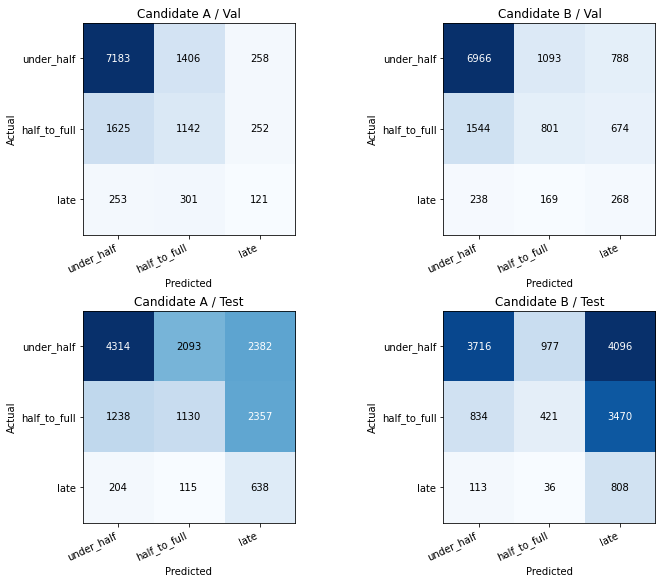

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for column, label in enumerate(candidate_rows):
    for row, split in enumerate(["Val", "Test"]):
        plot_confusion_matrix(candidate_results[label, split]["matrix"], axes[row, column], f"{label} / {split}")
plt.show()


### 10.8 Historical Summary

Tuned LR substantially exceeds Dummy on validation macro-F1 (0.4589 versus 0.2758). Candidate A was the preliminary overall candidate; Candidate B was the preliminary late-sensitive alternative, with more false warnings. Within the explored search region, changes in class weighting had a larger practical effect than nearby changes in C.

Candidate A was the best validation-selected tuned model, while plain LR achieved the highest Test Macro-F1 among the evaluated LR variants. This indicates that the validation improvement from tuning did not fully transfer to the later test period. A/B were selected using Validation only; Test did not participate in tuning rankings or model selection. Their Test results were evaluated only after the candidates were frozen.

## 11. Final Model Selection

**Formal overall candidate: Logistic Regression, C=10, class_weight="balanced".** It has the highest mean CV Macro-F1 (0.39945 +/- 0.03243), with mean MCC, balanced accuracy and lower Macro-F1 standard deviation as tie-breakers.

**CV-selected late-sensitive alternative: C=0.03, class_weight="balanced".** It maximises the eligible CV-mean business score, with mean late F1=0.16997 versus 0.16828 for the overall candidate. The advantage is marginal.

Retain the parameters already frozen in Section 9. Historical A/B and Test performance do not enter formal eligibility, ranking or selection.

## 12. Refit on Train + Validation

Use all 76,970 legal pre-Test development rows after confirming that every delivery label was mature before the Test cutoff. Refit the existing preprocessing and the frozen LR configurations on this development period; refit plain LR on the same rows for a fair reference.

The original combined refit/evaluation cell is retained intact in the next section. Within it, each estimator is fitted before its Test prediction; keeping this cell together preserves the existing execution logic and saved outputs.

## 13. Final Test Evaluation

Run the existing combined cell only after CV parameters are frozen. It refits on development, evaluates Test once per distinct configuration, and reports all metrics, per-class scores, predicted late share and confusion matrices. Test results do not reopen tuning or selection.

,Model,C,Weight,Accuracy,Macro-F1,Weighted-F1,Balanced Acc,MCC,Late Precision,Late Recall,Late F1,Late PR-AUC,Predicted Late Share (%)
0,Plain LR (development refit),1.00,None,0.5602,0.3970,0.5555,0.3988,0.1474,0.1242,0.0575,0.0786,0.1159,3.0613
1,CV-selected Overall Candidate,10.00,Balanced,0.2732,0.2357,0.3200,0.4342,0.1301,0.0884,0.9321,0.1614,0.1195,69.7533
2,CV-selected Late-sensitive Candidate,0.03,Balanced,0.2678,0.2309,0.3138,0.4318,0.1288,0.0877,0.9363,0.1603,0.1205,70.6378


,Model,Class,precision,recall,f1-score,support
0,Plain LR (development refit),under_half,0.6750,0.6571,0.6659,8789.0
1,Plain LR (development refit),half_to_full,0.4160,0.4819,0.4466,4725.0
2,Plain LR (development refit),late,0.1242,0.0575,0.0786,957.0
3,CV-selected Overall Candidate,under_half,0.8456,0.3227,0.4671,8789.0
4,CV-selected Overall Candidate,half_to_full,0.2209,0.0478,0.0786,4725.0
5,CV-selected Overall Candidate,late,0.0884,0.9321,0.1614,957.0
6,CV-selected Late-sensitive Candidate,under_half,0.8522,0.3155,0.4605,8789.0
7,CV-selected Late-sensitive Candidate,half_to_full,0.2070,0.0436,0.0720,4725.0
8,CV-selected Late-sensitive Candidate,late,0.0877,0.9363,0.1603,957.0


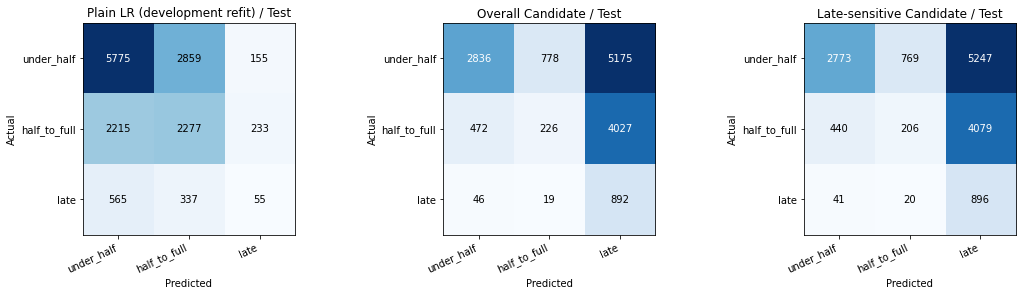

In [24]:
assert development[delivery_col].lt(test_cutoff).all()
final_preprocessor = clone(logistic_preprocessor).fit(development[features])
X_final_fit = csr_matrix(final_preprocessor.transform(development[features]))
X_final_test = csr_matrix(final_preprocessor.transform(test_df[features]))
final_configs = {"Plain LR (development refit)": {"C": 1.0, "Weight": "None"}, **frozen_cv_candidates}
final_cv_models, final_test_results, final_test_cache = {}, {}, {}
final_metric_rows, final_report_rows = [], []
for label, config in final_configs.items():
    key = (config["C"], config["Weight"])
    if key not in final_test_cache:
        estimator = clone(logistic_model.named_steps["model"]).set_params(
            C=config["C"], class_weight=lr_class_weight(config["Weight"]), max_iter=4000)
        with warnings.catch_warnings():
            warnings.simplefilter("error", ConvergenceWarning)
            estimator.fit(X_final_fit, development[TARGET])
        final_cv_models[key] = Pipeline([("preprocessor", final_preprocessor), ("model", estimator)])
        final_test_cache[key] = evaluate_cv_classifier(estimator, X_final_test, test_df[TARGET])
    result = final_test_cache[key]
    final_test_results[label] = result
    final_metric_rows.append({"Model": label, **config, **{k: result[k] for k in CV_METRICS},
                             "Predicted Late Share (%)": 100 * result["Predicted Late Share"]})
    final_report_rows.append(result["report"].assign(Model=label))
final_test_metrics = pd.DataFrame(final_metric_rows)
final_test_per_class = pd.concat(final_report_rows).rename_axis("Class").reset_index()
display(final_test_metrics.round(4))
display(final_test_per_class[["Model", "Class", "precision", "recall", "f1-score", "support"]].round(4))

fig, axes = plt.subplots(1, len(final_test_results), figsize=(15, 4), constrained_layout=True)
for ax, (label, result) in zip(axes, final_test_results.items()):
    plot_confusion_matrix(result["matrix"], ax, label.replace("CV-selected ", "") + " / Test")
plt.show()


## 14. Error and Temporal Generalization Analysis

CV estimates and Test results answer different temporal questions. Test remains a report of frozen choices, not a reason to reopen tuning. The conditional, non-nested Top16 selection and variability between folds limit how precisely development performance predicts the later period.

In [25]:
cv_plain_row = cv_tuning_results.loc[
    cv_tuning_results["C"].eq(1.0) & cv_tuning_results["Weight"].eq("None")].iloc[0]
cv_analysis_sources = {"Plain LR (development refit)": cv_plain_row,
                       **{row["Candidate"]: row for _, row in cv_candidate_summary.iterrows()}}
cv_temporal_generalization = pd.DataFrame([
    {"Model": row["Model"], "CV Macro-F1": cv_analysis_sources[row["Model"]]["Macro-F1 mean"],
     "Test Macro-F1": row["Macro-F1"], "CV Late F1": cv_analysis_sources[row["Model"]]["Late F1 mean"],
     "Test Late F1": row["Late F1"],
     "CV Predicted Late Share (%)": 100 * cv_analysis_sources[row["Model"]]["Predicted Late Share mean"],
     "Test Predicted Late Share (%)": row["Predicted Late Share (%)"]}
    for _, row in final_test_metrics.iterrows()])
display(cv_temporal_generalization.round(4))

,Model,CV Macro-F1,Test Macro-F1,CV Late F1,Test Late F1,CV Predicted Late Share (%),Test Predicted Late Share (%)
0,Plain LR (development refit),0.3564,0.3970,0.0000,0.0786,0.0114,3.0613
1,CV-selected Overall Candidate,0.3994,0.2357,0.1683,0.1614,21.9715,69.7533
2,CV-selected Late-sensitive Candidate,0.3992,0.2309,0.1700,0.1603,22.1403,70.6378


## 15. Conclusion

**Formal final model: CV-selected Overall Logistic Regression, C=10, class_weight="balanced".** Its mean CV Macro-F1 is 0.39945 +/- 0.03243, the highest in the fixed-feature LR search. The late-sensitive alternative (C=0.03, balanced) is nearly tied overall and offers only a small mean late-F1 improvement. The old custom-weight A/B remain preliminary single-validation candidates; their parameters were not carried forward as the formal CV selection.

Frozen Test evaluation exposes limited temporal generalization: the overall candidate's Macro-F1 falls to 0.23572, with late precision 0.08837 and 69.75% of orders predicted late. Test half_to_full recall is only 0.04783. Plain LR achieves higher final Test Macro-F1 (0.39702) but much lower late recall (0.05747 versus 0.93208). These results are reported without reopening selection or tuning; they do not demonstrate a reliable customer-warning model.

Top16 and every original split remain fixed. Test never entered CV, eligibility or ranking; all fold preprocessing used only mature fold-training rows. Feature selection was not nested inside CV, so the development scores must be interpreted as conditional on the already selected feature set.